In [20]:
import joblib
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [12]:
pca_data_abck = pd.read_csv('pca_data_abck.csv')
pca_data_abck.head()

data_fixed = pd.read_csv('data_fixed.csv')
data_fixed.head()

,cadmio,cobre,coliformes_termotolerantes,coliformes_totales,cromo,dbo5,dqo,hierro,manganeso,niquel,ph,plomo,solidos_suspendidos,solidos_totales,zinc,fecha,referencia
0,0.5,1.00,3000.0,3000.0,2.0,0.68,11.81,1.883,0.05285,4.0,8.20,10.0,41.0,313.0,0.13530,04/06/2001,P1
1,0.5,1.00,2200.0,7000.0,2.0,0.18,23.42,5.179,0.16410,4.0,8.36,10.0,185.0,453.0,0.09056,04/06/2001,P2
2,0.5,1.00,7000.0,17000.0,2.0,0.48,19.68,6.043,0.20470,4.0,8.47,10.0,209.0,470.0,0.09999,04/06/2001,P3
3,0.5,1.00,11000.0,11000.0,2.0,0.58,7.87,3.159,0.09761,4.0,8.34,10.0,74.0,350.0,0.09698,04/06/2001,P4
4,0.5,2.89,13000.0,13000.0,2.0,0.35,7.75,1.093,0.03675,5.2,8.44,10.0,0.0,293.0,0.11720,04/07/2001,P1


In [13]:
data_fixed["cluster"] = pca_data_abck['cluster_hibrido'].copy()
data_fixed.head()

,cadmio,cobre,coliformes_termotolerantes,coliformes_totales,cromo,dbo5,dqo,hierro,manganeso,niquel,ph,plomo,solidos_suspendidos,solidos_totales,zinc,fecha,referencia,cluster
0,0.5,1.00,3000.0,3000.0,2.0,0.68,11.81,1.883,0.05285,4.0,8.20,10.0,41.0,313.0,0.13530,04/06/2001,P1,2
1,0.5,1.00,2200.0,7000.0,2.0,0.18,23.42,5.179,0.16410,4.0,8.36,10.0,185.0,453.0,0.09056,04/06/2001,P2,2
2,0.5,1.00,7000.0,17000.0,2.0,0.48,19.68,6.043,0.20470,4.0,8.47,10.0,209.0,470.0,0.09999,04/06/2001,P3,2
3,0.5,1.00,11000.0,11000.0,2.0,0.58,7.87,3.159,0.09761,4.0,8.34,10.0,74.0,350.0,0.09698,04/06/2001,P4,2
4,0.5,2.89,13000.0,13000.0,2.0,0.35,7.75,1.093,0.03675,5.2,8.44,10.0,0.0,293.0,0.11720,04/07/2001,P1,2


In [14]:
# Calcular el perfil químico de cada cluster
perfil_quimico = data_fixed.drop(columns=['fecha', 'referencia']).groupby('cluster').mean()
perfil_quimico['frequencia'] = data_fixed.groupby('cluster').size()
display(perfil_quimico)

,cadmio,cobre,coliformes_termotolerantes,coliformes_totales,cromo,dbo5,dqo,hierro,manganeso,niquel,ph,plomo,solidos_suspendidos,solidos_totales,zinc,frequencia
cluster,,,,,,,,,,,,,,,,
0,23.479252,105.808443,1.524703e+05,4.003165e+05,466.728835,78.037779,27.777406,43.756427,7.749652,349.165137,7.728913,122.780262,311.418226,73.400619,4.351761,206
1,26.250000,48.080000,8.200000e+06,1.400000e+07,67.737000,3.637500,28.741500,90.115000,27.220000,152.214000,7.275000,77.550000,364.840000,24.892900,0.563830,2
2,10.823465,24.837496,5.394050e+04,7.691565e+04,106.036512,29.208240,30.813490,10.579559,0.639090,111.815324,8.084463,61.470243,217.422892,254.339551,0.409312,432


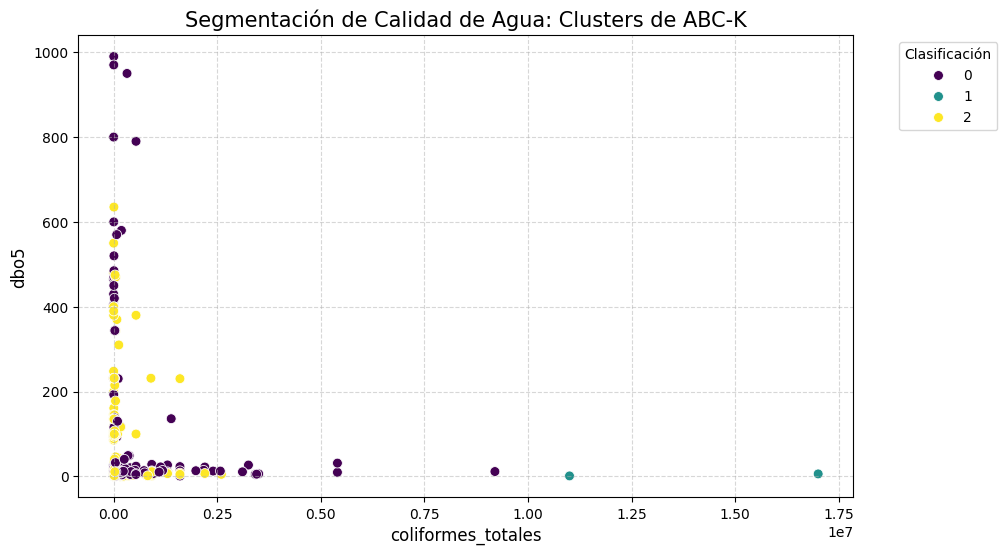

In [19]:
# data_fixed.plot(kind='scatter', x="cadmio", y='cobre', c='cluster', colormap='seismic', legend=True)

pca_labels = ['coliformes_totales', 'dbo5']

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=data_fixed, 
    x=pca_labels[0], 
    y=pca_labels[1], 
    hue='cluster', 
    palette='viridis', 
    s=50, 
    alpha=1,
    edgecolor='w'
)

# Personalización de títulos (basado en tu interpretación de loadings)
plt.title('Segmentación de Calidad de Agua: Clusters de ABC-K', fontsize=15)
plt.xlabel(f'{pca_labels[0]}', fontsize=12)
plt.ylabel(f'{pca_labels[1]}', fontsize=12)
plt.legend(title='Clasificación', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.50)
plt.show()
